<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/1_From_Visibility_to_Better_Decisions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

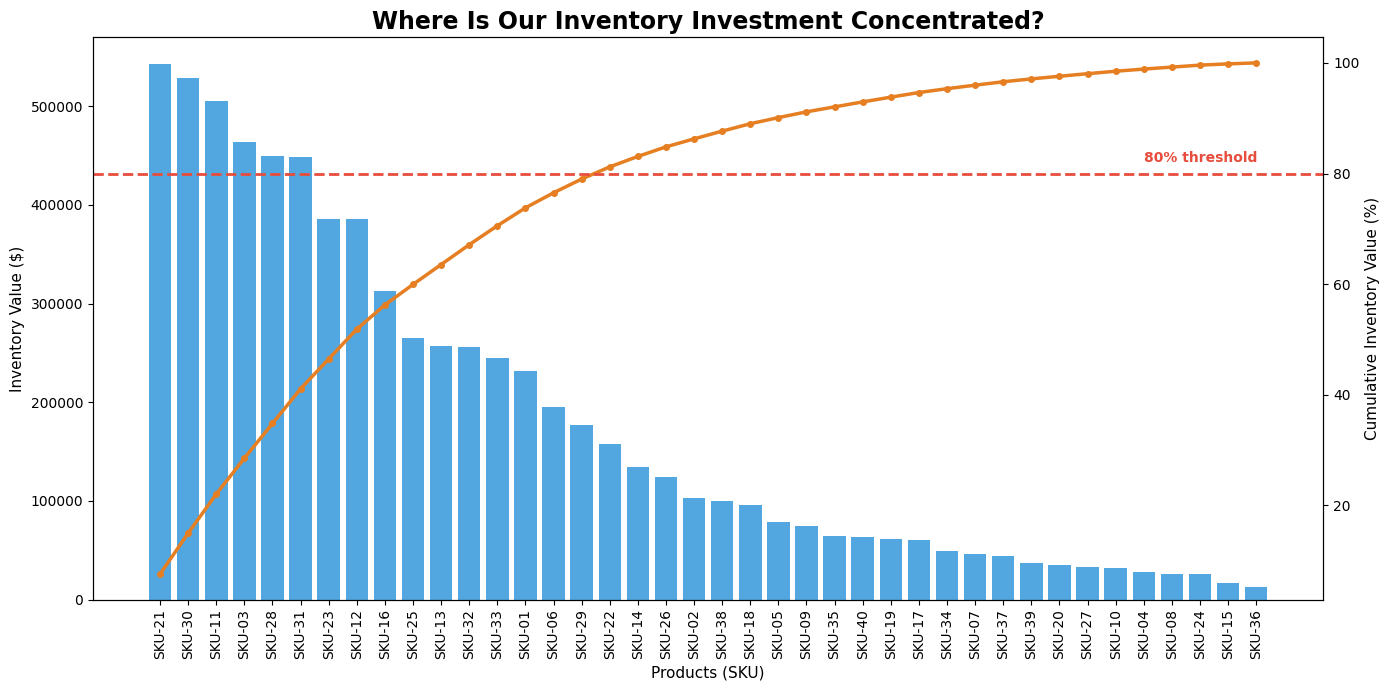

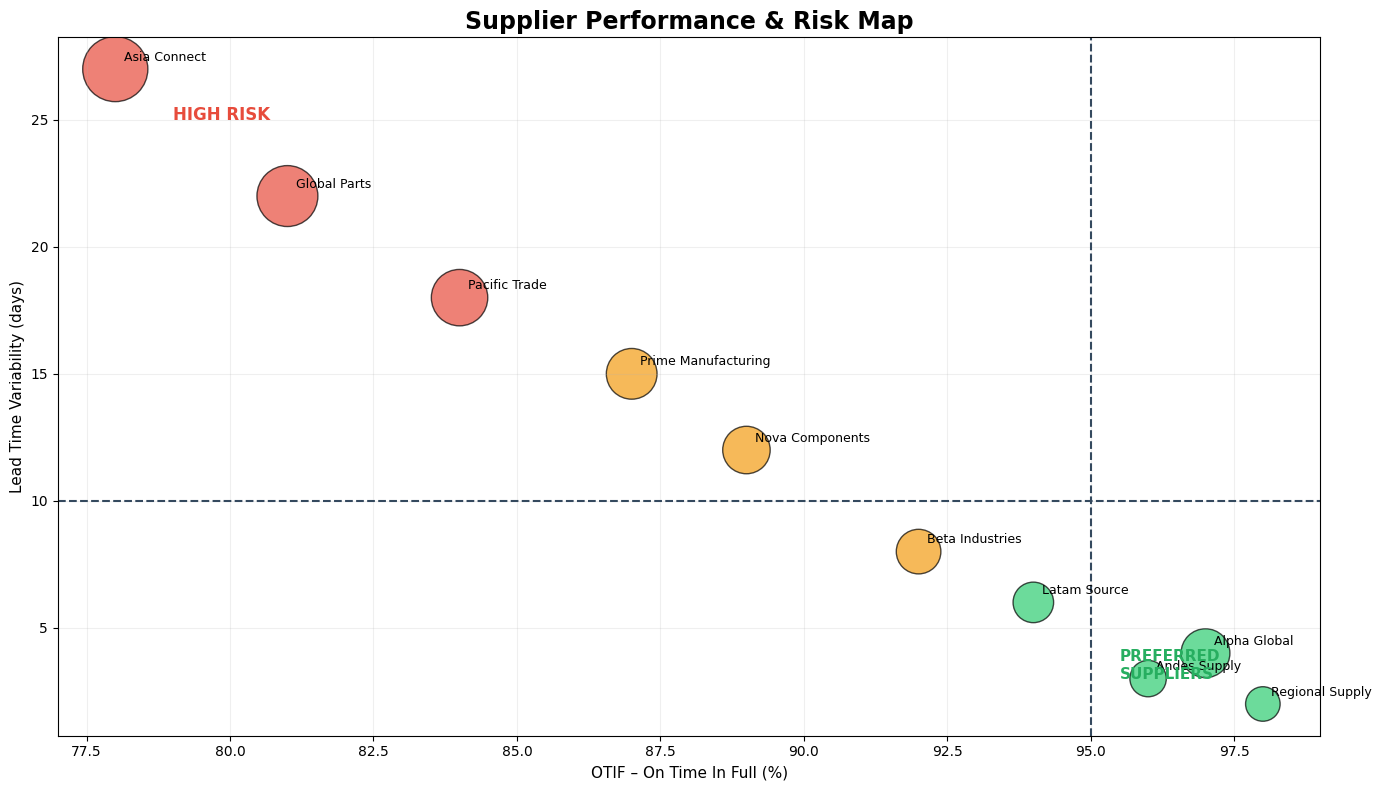

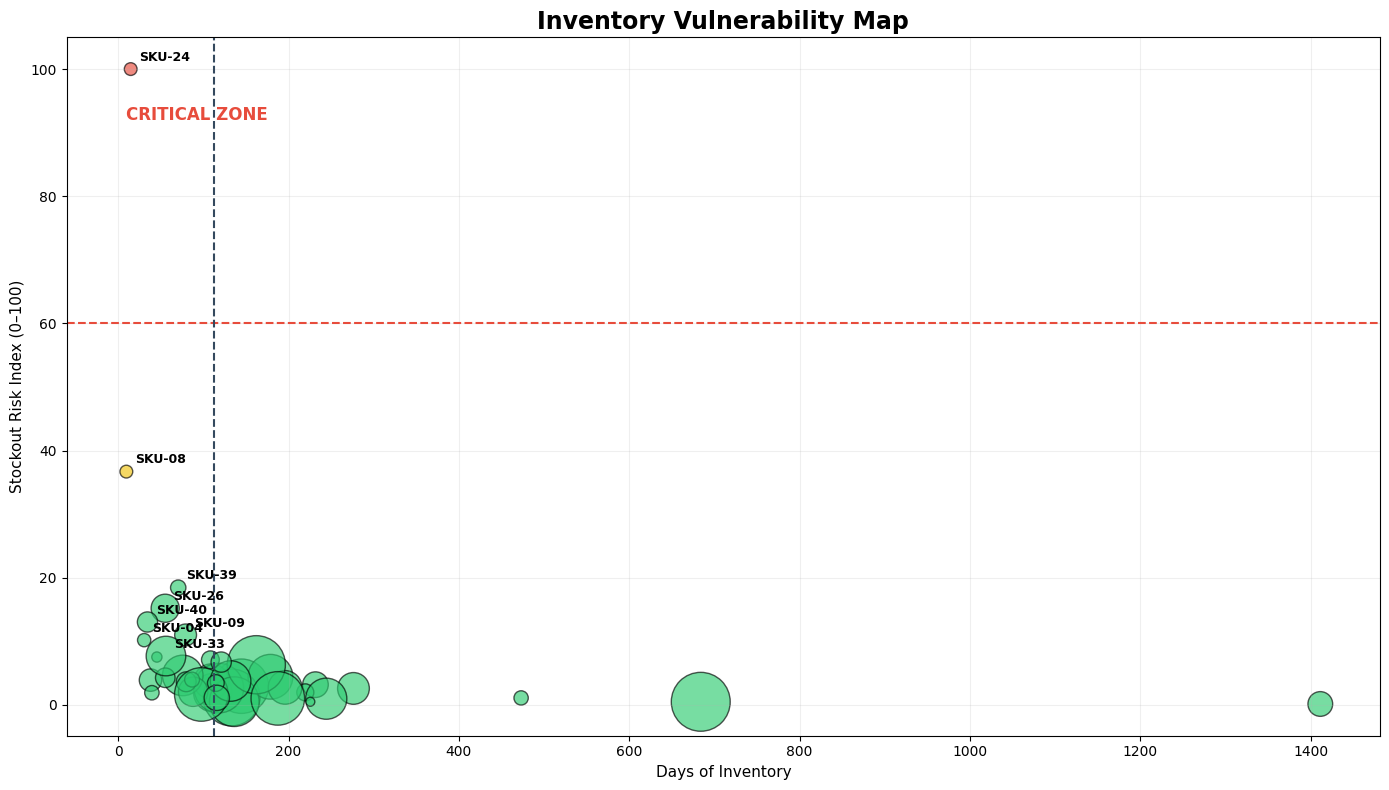

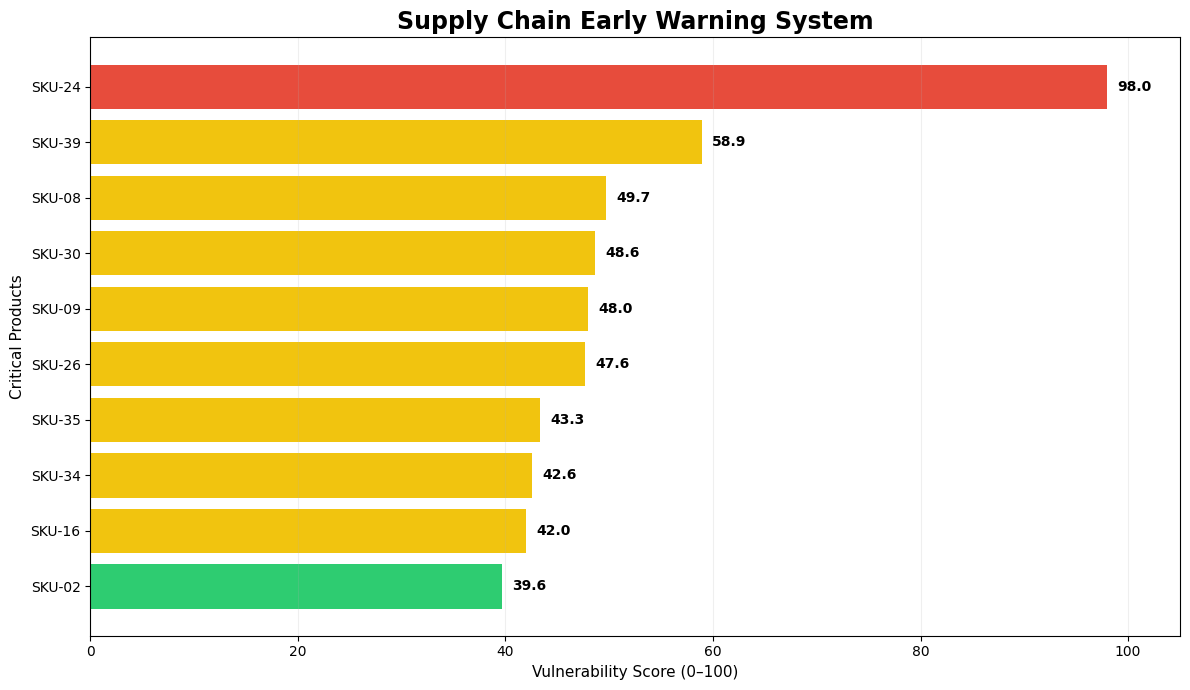

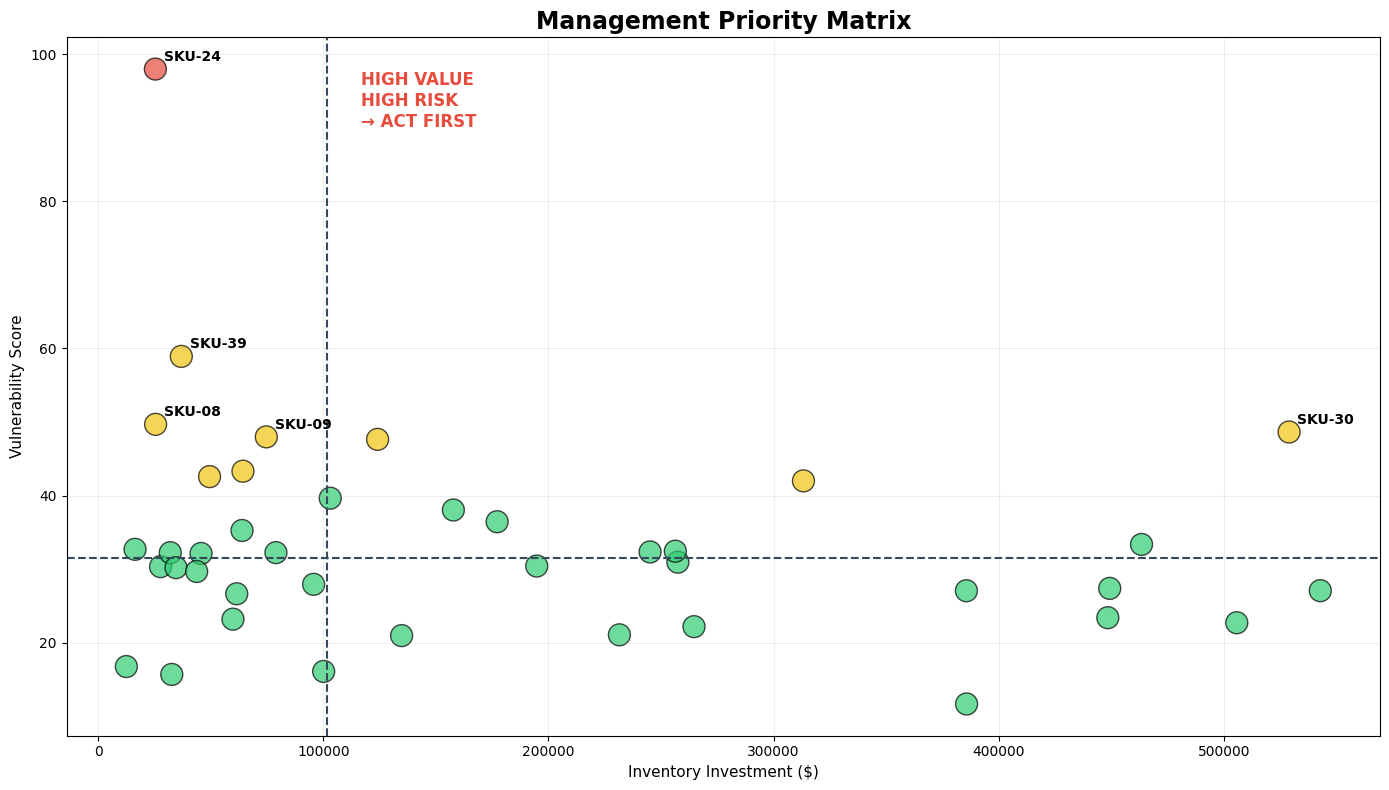


SUPPLY CHAIN MANAGEMENT SUMMARY

TOP 5 PRODUCTS REQUIRING MANAGEMENT ATTENTION

       SKU  Inventory_Value  Days_of_Inventory  Lead_Time  Stockout_Risk  \
23  SKU-24         25443.20              14.70         55         100.00   
38  SKU-39         36960.89              70.51         59          18.44   
7   SKU-08         25552.97               9.60         53          36.69   
29  SKU-30        528887.51             162.17         57           6.32   
8   SKU-09         74708.13              79.15         56          11.00   

    Vulnerability_Score  
23                97.97  
38                58.91  
7                 49.68  
29                48.63  
8                 47.97  

TOP 5 SUPPLIERS REQUIRING ATTENTION

              Supplier  OTIF  Lead_Time  Lead_Time_Variability  Quality_Score  \
8         Asia Connect    78         60                     27             79   
5         Global Parts    81         52                     22             82   
2        Pacific Trade   

In [1]:
# ================================================================
# SUPPLY CHAIN VISIBILITY & RISK ANALYTICS
# Inventories + Suppliers + Vulnerability + Early Warning
# ================================================================
#
# OBJETIVO:
# Este ejercicio busca transformar datos de inventarios y proveedores
# en información útil para la toma de decisiones.
#
# Vamos a responder cuatro preguntas:
#
# 1. ¿Dónde está concentrado el dinero invertido en inventario?
# 2. ¿Qué proveedores representan mayor riesgo?
# 3. ¿Qué productos son más vulnerables a un posible stockout?
# 4. ¿Qué productos deberían recibir atención primero?
#
# IMPORTANTE:
# No necesitamos cargar ningún archivo.
# Python creará automáticamente una base de datos ficticia.
# ================================================================


# ================================================================
# PASO 1. IMPORTAR LIBRERÍAS
# ================================================================

# pandas nos permite trabajar con tablas y bases de datos.
import pandas as pd

# numpy nos permite realizar cálculos numéricos y generar datos.
import numpy as np

# matplotlib nos permite crear las gráficas.
import matplotlib.pyplot as plt


# ================================================================
# PASO 2. CREAR UNA BASE DE DATOS FICTICIA DE INVENTARIOS
# ================================================================

# Esta instrucción permite obtener los mismos números aleatorios
# cada vez que ejecutamos el código.
np.random.seed(42)

# Número de productos que tendrá nuestra empresa ficticia.
n_skus = 40

# Creamos una tabla con 40 productos.
inventory = pd.DataFrame({

    # Código de cada producto.
    "SKU": [f"SKU-{i+1:02d}" for i in range(n_skus)],

    # Demanda anual de cada producto.
    "Annual_Demand": np.random.randint(500, 8000, n_skus),

    # Costo unitario.
    "Unit_Cost": np.random.uniform(10, 250, n_skus),

    # Cantidad disponible actualmente en inventario.
    "Inventory_Units": np.random.randint(100, 2500, n_skus),

    # Tiempo de reposición del proveedor en días.
    "Lead_Time": np.random.randint(5, 60, n_skus),

    # Variabilidad de la demanda.
    # Valores altos significan una demanda más impredecible.
    "Demand_Variability": np.random.uniform(0.05, 0.50, n_skus)
})


# ================================================================
# PASO 3. CALCULAR INDICADORES DE INVENTARIO
# ================================================================

# Valor monetario del inventario.
#
# Inventory Value = Inventory Units × Unit Cost

inventory["Inventory_Value"] = (
    inventory["Inventory_Units"] *
    inventory["Unit_Cost"]
)


# Calculamos la demanda promedio diaria.
#
# Daily Demand = Annual Demand / 365

inventory["Daily_Demand"] = (
    inventory["Annual_Demand"] / 365
)


# Calculamos cuántos días aproximadamente podría cubrir
# nuestro inventario actual.
#
# Days of Inventory = Inventory / Daily Demand

inventory["Days_of_Inventory"] = (
    inventory["Inventory_Units"] /
    inventory["Daily_Demand"]
)


# ================================================================
# PASO 4. CREAR UN INDICADOR SIMPLIFICADO DE RIESGO DE STOCKOUT
# ================================================================
#
# IMPORTANTE:
# Este NO es un modelo probabilístico formal de stockout.
# Es un índice didáctico para comparar productos.
#
# La lógica es:
#
# Mayor Lead Time             -> mayor riesgo
# Mayor Demand Variability    -> mayor riesgo
# Mayor cobertura inventario  -> menor riesgo
#
# Por eso usamos:
#
# Lead Time × Demand Variability
# --------------------------------
# Days of Inventory


inventory["Stockout_Risk"] = (
    inventory["Lead_Time"] *
    inventory["Demand_Variability"] /
    inventory["Days_of_Inventory"]
)


# Convertimos el indicador a una escala de 0 a 100.
#
# El producto más riesgoso tendrá un valor cercano a 100.

inventory["Stockout_Risk"] = (
    inventory["Stockout_Risk"] /
    inventory["Stockout_Risk"].max()
) * 100


# ================================================================
# PASO 5. CREAR UNA BASE FICTICIA DE PROVEEDORES
# ================================================================

suppliers = pd.DataFrame({

    "Supplier": [
        "Alpha Global",
        "Beta Industries",
        "Pacific Trade",
        "Andes Supply",
        "Nova Components",
        "Global Parts",
        "Latam Source",
        "Prime Manufacturing",
        "Asia Connect",
        "Regional Supply"
    ],

    # OTIF = On Time In Full
    # Porcentaje de pedidos entregados completos y a tiempo.
    "OTIF": [
        97, 92, 84, 96, 89,
        81, 94, 87, 78, 98
    ],

    # Tiempo promedio de entrega en días.
    "Lead_Time": [
        12, 25, 45, 8, 32,
        52, 18, 38, 60, 6
    ],

    # Variabilidad del tiempo de entrega.
    # Un número alto significa mayor incertidumbre.
    "Lead_Time_Variability": [
        4, 8, 18, 3, 12,
        22, 6, 15, 27, 2
    ],

    # Valor anual comprado a cada proveedor.
    "Purchase_Value": [
        900000, 750000, 1200000, 500000, 850000,
        1400000, 620000, 970000, 1600000, 450000
    ],

    # Calificación de calidad del proveedor.
    "Quality_Score": [
        96, 91, 85, 97, 88,
        82, 93, 86, 79, 98
    ]
})


# ================================================================
# PASO 6. CALCULAR UN SUPPLIER RISK SCORE
# ================================================================
#
# Vamos a combinar diferentes dimensiones del riesgo.
#
# 35% = problemas de cumplimiento OTIF
# 30% = variabilidad del lead time
# 20% = problemas de calidad
# 15% = duración del lead time
#
# Los pesos pueden ser modificados por los estudiantes.


suppliers["Supplier_Risk"] = (

    (100 - suppliers["OTIF"]) * 0.35 +

    suppliers["Lead_Time_Variability"] * 0.30 +

    (100 - suppliers["Quality_Score"]) * 0.20 +

    suppliers["Lead_Time"] * 0.15
)


# Normalizamos nuevamente entre 0 y 100.

suppliers["Supplier_Risk"] = (
    suppliers["Supplier_Risk"] /
    suppliers["Supplier_Risk"].max()
) * 100


# ================================================================
# GRÁFICA 1
# WHERE IS OUR INVENTORY INVESTMENT CONCENTRATED?
# ================================================================
#
# Esta gráfica combina:
#
# BARRAS = valor de inventario por producto
# LÍNEA  = porcentaje acumulado del valor
#
# Es similar a un análisis de Pareto.
# ================================================================


# Ordenamos los productos de mayor a menor valor de inventario.

pareto = inventory.sort_values(
    "Inventory_Value",
    ascending=False
).copy()


# Calculamos el porcentaje acumulado.

pareto["Cumulative_Value"] = (
    pareto["Inventory_Value"].cumsum() /
    pareto["Inventory_Value"].sum()
) * 100


# Creamos la figura.

fig, ax = plt.subplots(figsize=(14, 7))


# Barras azules = valor del inventario.

ax.bar(
    pareto["SKU"],
    pareto["Inventory_Value"],
    color="#3498DB",
    alpha=0.85
)


# Título.

ax.set_title(
    "Where Is Our Inventory Investment Concentrated?",
    fontsize=17,
    fontweight="bold"
)


ax.set_xlabel(
    "Products (SKU)",
    fontsize=11
)

ax.set_ylabel(
    "Inventory Value ($)",
    fontsize=11
)


# Rotamos las etiquetas para facilitar su lectura.

ax.tick_params(
    axis="x",
    rotation=90
)


# Creamos un segundo eje vertical para el porcentaje acumulado.

ax2 = ax.twinx()


# Línea naranja = porcentaje acumulado.

ax2.plot(
    pareto["SKU"],
    pareto["Cumulative_Value"],
    color="#E67E22",
    marker="o",
    markersize=4,
    linewidth=2.5
)


# Línea roja = referencia del 80%.

ax2.axhline(
    80,
    color="#E74C3C",
    linestyle="--",
    linewidth=2
)


ax2.set_ylabel(
    "Cumulative Inventory Value (%)",
    fontsize=11
)


# Agregamos una etiqueta para destacar el 80%.

ax2.text(
    len(pareto) - 5,
    82,
    "80% threshold",
    color="#E74C3C",
    fontweight="bold"
)


plt.tight_layout()
plt.show()


# ================================================================
# GRÁFICA 2
# SUPPLIER RISK MAP
# ================================================================
#
# Queremos analizar simultáneamente:
#
# EJE X  = OTIF
# EJE Y  = variabilidad del Lead Time
# BURBUJA = dinero comprado al proveedor
#
# Cuanto más grande la burbuja,
# mayor exposición económica tenemos con ese proveedor.
# ================================================================


plt.figure(figsize=(14, 8))


# Convertimos Purchase Value en tamaño de burbuja.

bubble_size = (
    suppliers["Purchase_Value"] /
    suppliers["Purchase_Value"].max()
) * 2200


# Creamos colores según el Supplier Risk.

supplier_colors = []

for risk in suppliers["Supplier_Risk"]:

    if risk < 35:
        supplier_colors.append("#2ECC71")   # Verde

    elif risk < 65:
        supplier_colors.append("#F39C12")   # Naranja

    else:
        supplier_colors.append("#E74C3C")   # Rojo


# Creamos las burbujas.

plt.scatter(
    suppliers["OTIF"],
    suppliers["Lead_Time_Variability"],
    s=bubble_size,
    c=supplier_colors,
    alpha=0.70,
    edgecolors="black"
)


# Colocamos el nombre de cada proveedor.

for i, row in suppliers.iterrows():

    plt.annotate(
        row["Supplier"],
        (
            row["OTIF"],
            row["Lead_Time_Variability"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )


# OTIF de 95% como referencia.

plt.axvline(
    95,
    color="#34495E",
    linestyle="--",
    linewidth=1.5
)


# Variabilidad mediana como referencia.

median_variability = suppliers[
    "Lead_Time_Variability"
].median()


plt.axhline(
    median_variability,
    color="#34495E",
    linestyle="--",
    linewidth=1.5
)


plt.title(
    "Supplier Performance & Risk Map",
    fontsize=17,
    fontweight="bold"
)


plt.xlabel(
    "OTIF – On Time In Full (%)",
    fontsize=11
)


plt.ylabel(
    "Lead Time Variability (days)",
    fontsize=11
)


# Indicamos zonas gerenciales.

plt.text(
    79,
    25,
    "HIGH RISK",
    fontsize=12,
    fontweight="bold",
    color="#E74C3C"
)


plt.text(
    95.5,
    3,
    "PREFERRED\nSUPPLIERS",
    fontsize=11,
    fontweight="bold",
    color="#27AE60"
)


plt.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ================================================================
# GRÁFICA 3
# INVENTORY VULNERABILITY MAP
# ================================================================
#
# Ahora relacionamos:
#
# X = días disponibles de inventario
# Y = riesgo de stockout
#
# Tamaño de la burbuja = dinero invertido en inventario.
#
# Esto permite detectar productos que combinan:
#
# - poca cobertura
# - alto riesgo
# - alta inversión
# ================================================================


plt.figure(figsize=(14, 8))


# Tamaño de las burbujas.

bubble_inventory = (
    inventory["Inventory_Value"] /
    inventory["Inventory_Value"].max()
) * 1800


# Definimos colores según riesgo de stockout.

inventory_colors = []

for risk in inventory["Stockout_Risk"]:

    if risk < 30:
        inventory_colors.append("#2ECC71")

    elif risk < 60:
        inventory_colors.append("#F1C40F")

    else:
        inventory_colors.append("#E74C3C")


# Dibujamos las burbujas.

plt.scatter(
    inventory["Days_of_Inventory"],
    inventory["Stockout_Risk"],
    s=bubble_inventory,
    c=inventory_colors,
    alpha=0.65,
    edgecolors="black"
)


# Seleccionamos los 8 productos con mayor riesgo.

critical = inventory.nlargest(
    8,
    "Stockout_Risk"
)


# Mostramos únicamente sus nombres para evitar saturar la gráfica.

for i, row in critical.iterrows():

    plt.annotate(
        row["SKU"],
        (
            row["Days_of_Inventory"],
            row["Stockout_Risk"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )


# Línea horizontal de referencia de riesgo.

plt.axhline(
    60,
    color="#E74C3C",
    linestyle="--",
    linewidth=1.5
)


# Línea vertical = mediana de cobertura.

median_days = inventory[
    "Days_of_Inventory"
].median()


plt.axvline(
    median_days,
    color="#34495E",
    linestyle="--",
    linewidth=1.5
)


plt.title(
    "Inventory Vulnerability Map",
    fontsize=17,
    fontweight="bold"
)


plt.xlabel(
    "Days of Inventory",
    fontsize=11
)


plt.ylabel(
    "Stockout Risk Index (0–100)",
    fontsize=11
)


plt.text(
    inventory["Days_of_Inventory"].min(),
    92,
    "CRITICAL ZONE",
    fontsize=12,
    fontweight="bold",
    color="#E74C3C"
)


plt.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ================================================================
# PASO 7. CREAR UN VULNERABILITY SCORE
# ================================================================
#
# Queremos combinar tres factores:
#
# Stockout Risk       = 45%
# Lead Time           = 30%
# Demand Variability  = 25%
#
# Este indicador servirá como un sistema sencillo
# de alerta temprana.
# ================================================================


inventory["Vulnerability_Score"] = (

    inventory["Stockout_Risk"] * 0.45 +

    (
        inventory["Lead_Time"] /
        inventory["Lead_Time"].max()
        * 100
    ) * 0.30 +

    (
        inventory["Demand_Variability"] /
        inventory["Demand_Variability"].max()
        * 100
    ) * 0.25
)


# ================================================================
# GRÁFICA 4
# SUPPLY CHAIN EARLY WARNING SYSTEM
# ================================================================
#
# Seleccionamos los 10 productos que requieren mayor atención.
# ================================================================


alerts = inventory.nlargest(
    10,
    "Vulnerability_Score"
).sort_values(
    "Vulnerability_Score"
)


# Creamos colores según nivel de vulnerabilidad.

alert_colors = []

for score in alerts["Vulnerability_Score"]:

    if score < 40:
        alert_colors.append("#2ECC71")

    elif score < 60:
        alert_colors.append("#F1C40F")

    elif score < 75:
        alert_colors.append("#E67E22")

    else:
        alert_colors.append("#E74C3C")


plt.figure(figsize=(12, 7))


plt.barh(
    alerts["SKU"],
    alerts["Vulnerability_Score"],
    color=alert_colors
)


plt.title(
    "Supply Chain Early Warning System",
    fontsize=17,
    fontweight="bold"
)


plt.xlabel(
    "Vulnerability Score (0–100)",
    fontsize=11
)


plt.ylabel(
    "Critical Products",
    fontsize=11
)


# Mostramos el valor de cada barra.

for index, value in enumerate(
    alerts["Vulnerability_Score"]
):

    plt.text(
        value + 1,
        index,
        f"{value:.1f}",
        va="center",
        fontweight="bold"
    )


plt.xlim(
    0,
    105
)

plt.grid(
    axis="x",
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ================================================================
# GRÁFICA 5
# MANAGEMENT PRIORITY MATRIX
# ================================================================
#
# Esta gráfica busca responder:
#
# ¿Dónde debería actuar primero la gerencia?
#
# X = dinero invertido
# Y = vulnerabilidad
#
# Un producto que tenga:
#
# ALTA INVERSIÓN + ALTA VULNERABILIDAD
#
# debería recibir especial atención.
# ================================================================


plt.figure(figsize=(14, 8))


priority_colors = []

for score in inventory["Vulnerability_Score"]:

    if score < 40:
        priority_colors.append("#2ECC71")

    elif score < 60:
        priority_colors.append("#F1C40F")

    elif score < 75:
        priority_colors.append("#E67E22")

    else:
        priority_colors.append("#E74C3C")


plt.scatter(
    inventory["Inventory_Value"],
    inventory["Vulnerability_Score"],
    s=250,
    c=priority_colors,
    alpha=0.70,
    edgecolors="black"
)


# Líneas que dividen la gráfica en cuatro cuadrantes.

median_value = inventory[
    "Inventory_Value"
].median()

median_risk = inventory[
    "Vulnerability_Score"
].median()


plt.axvline(
    median_value,
    color="#34495E",
    linestyle="--"
)

plt.axhline(
    median_risk,
    color="#34495E",
    linestyle="--"
)


# Identificamos los cinco productos más vulnerables.

top_priority = inventory.nlargest(
    5,
    "Vulnerability_Score"
)


for i, row in top_priority.iterrows():

    plt.annotate(
        row["SKU"],
        (
            row["Inventory_Value"],
            row["Vulnerability_Score"]
        ),
        xytext=(6,6),
        textcoords="offset points",
        fontweight="bold"
    )


plt.title(
    "Management Priority Matrix",
    fontsize=17,
    fontweight="bold"
)


plt.xlabel(
    "Inventory Investment ($)",
    fontsize=11
)

plt.ylabel(
    "Vulnerability Score",
    fontsize=11
)


plt.text(
    median_value * 1.15,
    inventory["Vulnerability_Score"].max() * 0.92,
    "HIGH VALUE\nHIGH RISK\n→ ACT FIRST",
    fontsize=12,
    fontweight="bold",
    color="#E74C3C"
)


plt.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ================================================================
# PASO 8. RESUMEN GERENCIAL
# ================================================================
#
# Finalmente, Python nos muestra cuáles productos
# y proveedores deberían ser analizados primero.
# ================================================================


print("\n" + "=" * 65)

print(
    "SUPPLY CHAIN MANAGEMENT SUMMARY"
)

print("=" * 65)


# ------------------------------------------------
# PRODUCTOS MÁS VULNERABLES
# ------------------------------------------------

print(
    "\nTOP 5 PRODUCTS REQUIRING MANAGEMENT ATTENTION\n"
)


print(

    inventory.nlargest(
        5,
        "Vulnerability_Score"
    )[

        [
            "SKU",
            "Inventory_Value",
            "Days_of_Inventory",
            "Lead_Time",
            "Stockout_Risk",
            "Vulnerability_Score"
        ]

    ].round(2)

)


# ------------------------------------------------
# PROVEEDORES MÁS RIESGOSOS
# ------------------------------------------------

print(
    "\nTOP 5 SUPPLIERS REQUIRING ATTENTION\n"
)


print(

    suppliers.nlargest(
        5,
        "Supplier_Risk"
    )[

        [
            "Supplier",
            "OTIF",
            "Lead_Time",
            "Lead_Time_Variability",
            "Quality_Score",
            "Supplier_Risk"
        ]

    ].round(2)

)


# ================================================================
# FIN DEL EJERCICIO
# ================================================================